# Document Processing with OCR

Aim is to build an agent for document processing with `Optical Character Recognition (OCR)`. 

**Objectives:**
- Parsing and extracting information from documents 
- Building an agent equipped with an OCR tool
- Identifying failure modes of OCR

## Background

Document processing converts unstructured documents meant for humans into structured data meant for machines. When documents are scanned images, OCR converts pixels to text. However, OCR alone produces raw text. Using LLMs, we can make sense of it.  

## Outline

- [1. Import Libraries](#1)
- [2. Create OCR Tool](#2)
  - [2.1. Use OCR to Parse a Sample Document](#2-1)
  - [2.2. Use Regex to Extract Information](#2-2)
- [3. Create the Agent](#3)
- [4. Run the Agent and Extract Information](#4)
- [5. OCR Limitations](#5)

<a id="1"></a>

## 1. Import Libraries

Import the packages needed for the document processing system:

- **Pillow (PIL)**: Load and manipulate images
- **Pytesseract**: Python wrapper for Tesseract OCR engine
- **LangChain**: Framework for building tool-enabled LLM applications
- **OpenRouter**: Open Source LLM inference provider

In [21]:
import os
import re

from dotenv import load_dotenv
from IPython.display import display

import pytesseract
from PIL import Image

from langchain.tools import tool
from langchain_openrouter import ChatOpenRouter
from langchain_classic.agents import AgentExecutor
from langchain_classic.agents import create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

<a id="2"></a>

## 2. Create OCR Tool

The `@tool` decorator from LangChain transforms a function into a tool for use by agents.

In [ ]:
@tool
def ocr_read_document(image_path: str) -> str:
    """Reads an image from the given path and returns extracted text using OCR."""
    try:
        text = pytesseract.image_to_string(Image.open(image_path))
        return text
    except Exception as e:
        return f"Error reading image: {e}"

<a id="2-1"></a>

### 2.1. Use OCR to Parse a Sample Document

Here's a clean digital invoice with crisp fonts, no handwriting, and no shadows. 

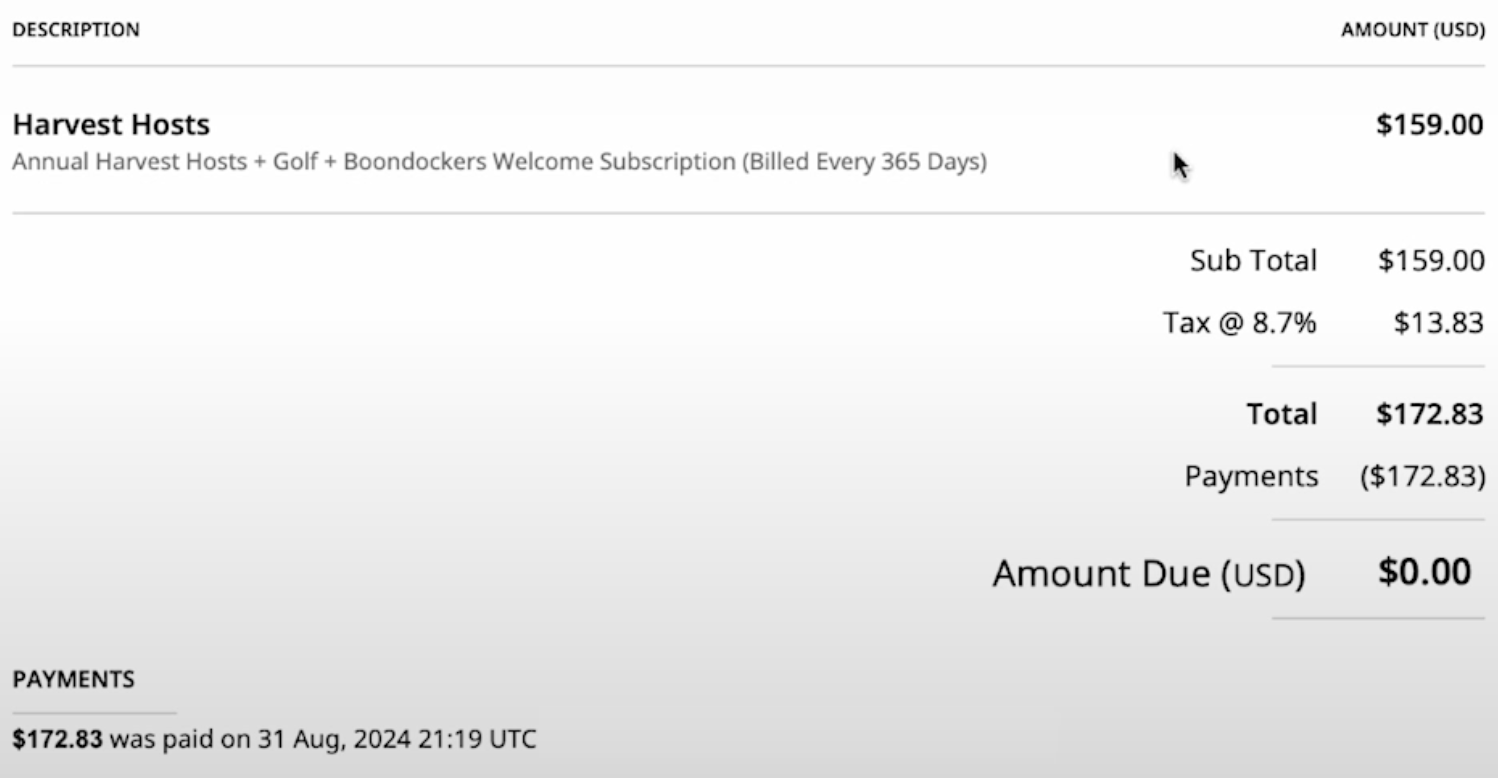

In [ ]:
image_path = 'artifacts/invoice-01.png'
img = Image.open(image_path)
display(img)

Now run the OCR tool on the invoice. 

In [3]:
ocr_text = ocr_read_document.run(image_path)
print("Raw OCR Output:\n----------------\n", ocr_text)

Raw OCR Output:
----------------
 DESCRIPTION AMOUNT (USD)

Harvest Hosts $159.00
Annual Harvest Hosts + Golf + Boondockers Welcome Subscription (Billed Every 365 Days) hk

Sub Total $159.00
Tax @ 8.7% $13.83

Total $172.83
Payments ($172.83)

Amount Due (USD) $0.00

PAYMENTS

$172.83 was paid on 31 Aug, 2024 21:19 UTC



<a id="2-2"></a>

### 2.2. Use Regex to Extract Information

Let's use regular expressions (regex) to extract tax and total from the parsed invoice. The patterns will look for "Tax" and "Total" to capture the respective numbers allowing for optional spacing and dollar sign.

In [4]:
# Regex to find Tax or Total
tax_match = re.search(r'Tax\s*\$?([0-9.,]+)', ocr_text)
total_match = re.search(r'Total\s*\$?([0-9.,]+)', ocr_text)

# Print tax amount if found
if tax_match:
    print("Tax found by regex:", tax_match.group(1))
else:
    print("Tax not found by regex.")

# Print total amount if found
if total_match:
    print("Total found by regex:", total_match.group(1))
else:
    print("Total not found by regex.")

Tax not found by regex.
Total found by regex: 159.00


**Discussion of the output:**

- The regex pattern for "Tax" failed because the OCR output had "Tax @", not just "Tax."
- The regex pattern matched "Sub Total" instead of "Total" because it appeared first and fit the pattern.

<a id="3"></a>

## 3. Create the Agent

Let's build an agent to parse and extract information from the invoice. For parsing, OCR is used as a tool. For extracting, LLM is used as opposed to regex.


In [5]:
# Load environment variables from .env
_ = load_dotenv(override=True)

# Verify that all required API keys are available
for key in ["OPENROUTER_API_KEY", "LANGSMITH_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and everything is set up.")

Environment variables loaded and everything is set up.


Here, load the API key for OpenAI from a configuration file. 

In [ ]:
# 1. Define the list of tools
tools = [ocr_read_document]

# 2. Set up the OpenRouter model
llm = ChatOpenRouter(
    model="openrouter/free", 
    temperature=1
)

Now create the agent using the ReAct framework with the LLM, tools, and prompt. Then set up the `AgentExecutor` to run the agent loop. 

In [ ]:
# 3. Create the OpenAI-compatible prompt
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant designed to extract information from documents." 
            "You have access to this tool: "
            "OCR tool to extract raw text from images "
        ),
        ("human", "{input}"),
        MessagesPlaceholder(variable_name="agent_scratchpad"),
    ]
)

# 4. Create a proper tool-calling agent
agent = create_tool_calling_agent(llm, tools, prompt)

# 5. Set up the AgentExecutor to run the tool-enabled loop
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, handle_parsing_errors=True)

<a id="4"></a>

## 4. Run the Agent and Extract Information

Having implemented the agent, we can pass it a prompt for parsing and extracting information from the invoice.


During the agent loop, the LLM decides when to call the OCR tool, receives the text output, and continues reasoning.

In [8]:
task = """
Please process the document at 'artifacts/invoice-01.png' using the OCR tool 
and extract the following information in JSON format:
- tax
- total
"""

# Use .invoke() with a dictionary input for the agent_executor
response = agent_executor.invoke({"input": task})



> Entering new AgentExecutor chain...

Invoking: `ocr_read_document` with `{'image_path': 'artifacts/invoice-01.png'}`


DESCRIPTION AMOUNT (USD)

Harvest Hosts $159.00
Annual Harvest Hosts + Golf + Boondockers Welcome Subscription (Billed Every 365 Days) hk

Sub Total $159.00
Tax @ 8.7% $13.83

Total $172.83
Payments ($172.83)

Amount Due (USD) $0.00

PAYMENTS

$172.83 was paid on 31 Aug, 2024 21:19 UTC

{"tax": "$13.83", "total": "$172.83"}


> Finished chain.


**Discussion of the Output:**

The agent returns JSON with the correct tax and total (not the subtotal). The LLM's comprehension capabilities enable the agent to extract information correctly based on the OCR output.

<a id="5"></a>

## 5. OCR Limitations

The combination of OCR for parsing and regex for extracting worked on the previous example. However real-world documents can have complex layout or low resolution. Let's explore three examples. 

### 5.1. Complex Tables

Tables are difficult for OCR. Misalignment of entries with unclear delineation between rows and columns can lead to poor results.  

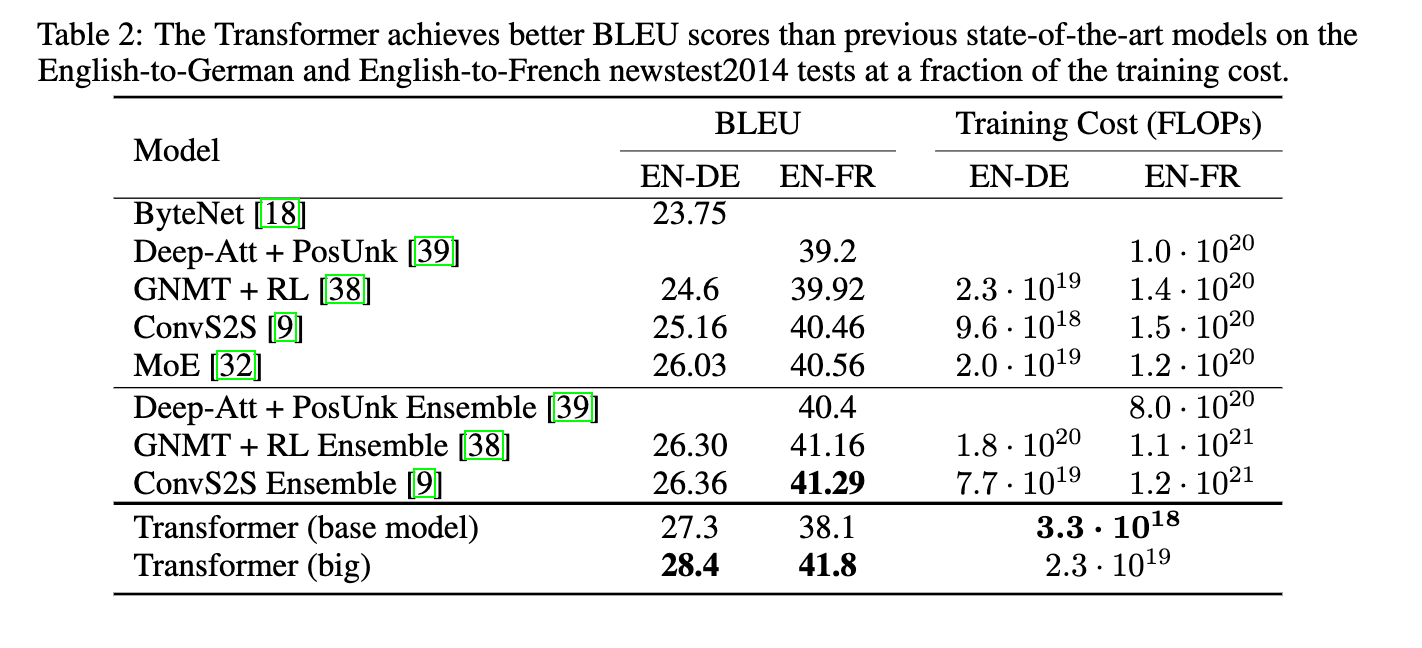

In [19]:
image_path = 'artifacts/table-01.png'
img = Image.open(image_path)
display(img)

Extract the training cost in FLOPs from the EN-DE column.

In [20]:
task = """
Extract the Training Cost (FLOPs) for EN-DE for ALL methods from the `artifacts/table-01.png` 
using the OCR tool.
Return as a list with model name and its training cost.
"""

# First, get the raw OCR output
ocr_output = ocr_read_document.run(image_path)

# Use .invoke() with a dictionary input for the agent_executor
response = agent_executor.invoke({"input": task})

# Display results side by side
print("="*80)
print(" " * 22 + "OCR TABLE RESULTS")
print("="*80)
print("\n" + "─"*35 + " OCR OUTPUT " + "─"*33)
print(ocr_output[:600] + "..." if len(ocr_output) > 600 else ocr_output)
print("\n" + "─"*35 + " LLM RESULT " + "─"*33)
print(response["output"])
print("="*80)



> Entering new AgentExecutor chain...

Invoking: `ocr_read_document` with `{'image_path': 'artifacts/table-01.png'}`


Table 2: The Transformer achieves better BLEU scores than previous state-of-the-art models on the
English-to-German and English-to-French newstest2014 tests at a fraction of the training cost.

Model BLEU Training Cost (FLOPs)
owe EN-DE EN-FR EN-DE EN-FR

ByteNet [18] 23.75

Deep-Att + PosUnk [39] 39.2 1.0 - 102°
GNMT + RL [38| 24.6 39.92 2.3-10'9 1.4-10?°
ConvS28S [9 25.16 40.46 9.6-10'8 1.5-10?°
MoE [32] 26.03 40.56 2.0-10'9 1.2-10?°
Deep-Att + PosUnk Ensemble [39] 40.4 8.0 - 1029
GNMT + RL Ensemble [38| 26.30 41.16 1.8-1079  1.1- 10?!
ConvS2S Ensemble [9 26.36 41.29 7.7-10'9 —1.2- 1021
Transformer (base model) 27.3 38.1 3.3 - 1018

Transformer (big) 28.4 41.8 2.3 - 1019


Invoking: `ocr_read_document` with `{'image_path': 'artifacts/table-01.png'}`
responded: 
Let me parse the OCR text more carefully to extract the EN-DE Training Cost (FLOPs) for each model.



Ta

There are several issues with the results: 

- Exponents become apostrophes/degree
- Decimals become exclamation points
- Columns are misaligned

While the LLM can recognize patterns like empty cells, it may extract incorrect values from wrong columns due to garbled OCR output.

### 5.2. Handwriting

OCR struggles with handwriting. This is a fill-in-the-blanks exercise.

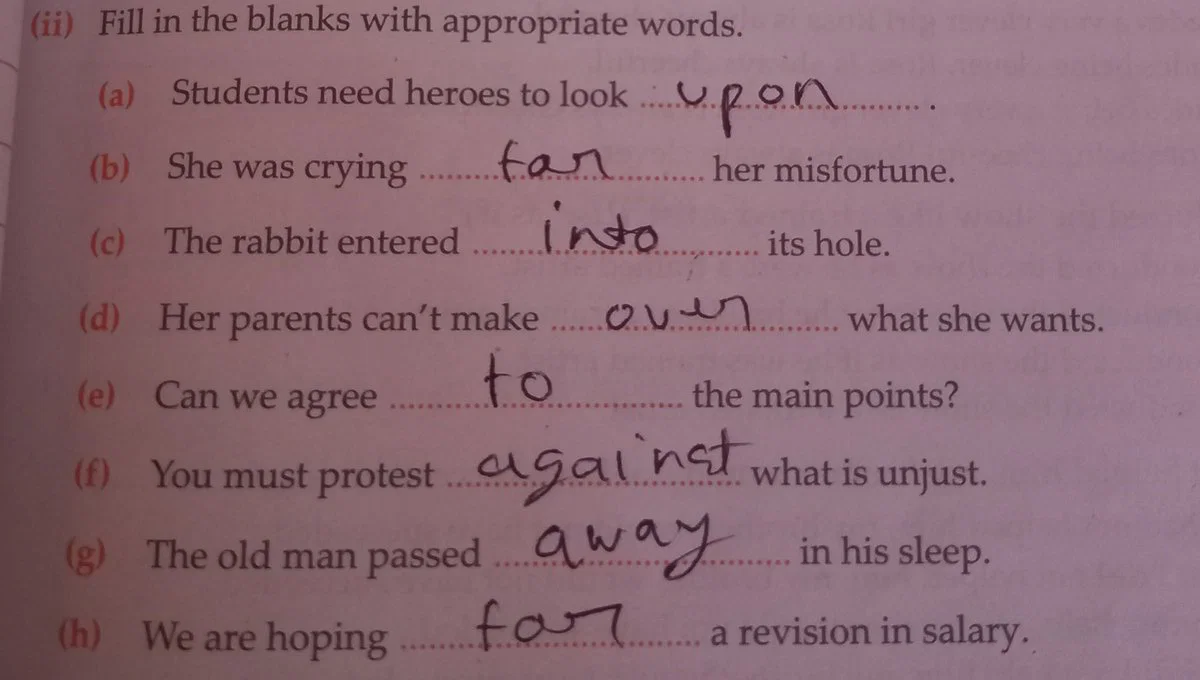

In [11]:
image_path = 'artifacts/handwriting-01.png'
img = Image.open(image_path)
display(img)

Extract the student name and all answers from the handwritten worksheet.

In [14]:
task = """
Please process the document at 'artifacts/handwriting-01.png' using ocr 
and extract the following information in JSON format:
- `student answer to all the questions`
"""

# First, get the raw OCR output
ocr_output = ocr_read_document.run(image_path)

# Use .invoke() with a dictionary input for the agent_executor
response = agent_executor.invoke({"input": task})

# Display results side by side
print("="*80)
print(" " * 22 + "HANDWRITTEN WORKSHEET RESULTS")
print("="*80)
print("\n" + "─"*35 + " OCR OUTPUT " + "─"*33)
print(ocr_output[:600] + "..." if len(ocr_output) > 600 else ocr_output)
print("\n" + "─"*35 + " LLM RESULT " + "─"*33)
print(response["output"])
print("="*80)



> Entering new AgentExecutor chain...

Invoking: `ocr_read_document` with `{'image_path': 'artifacts/handwriting-01.png'}`
responded: 



ij] in the blanks with appropriate words.

_ Students need heroes to look eee (ne ;
| She was crying ......... oS ee her misfortune.
rabbit entered ........ LAO. ed its hole.

ler parents can’t make ......2..47).......... what she wants.
Betmiass.t2 ©.............. the main points?
cakes ALK what is unjust.

tert mil st a revision in salary.

{"student answer to all the questions": {"question_1": "nee", "question_2": "over", "question_3": "LAO", "question_4": "ALK", "question_5": "ert"}}


> Finished chain.
                      HANDWRITTEN WORKSHEET RESULTS

─────────────────────────────────── OCR OUTPUT ─────────────────────────────────
ij] in the blanks with appropriate words.

_ Students need heroes to look eee (ne ;
| She was crying ......... oS ee her misfortune.
rabbit entered ........ LAO. ed its hole.

ler parents can’t make ......2..47)..

It couldn't actually detect the handwritten words properly. So the answers in the json format is wrong.

### 5.3. Low-Quality Receipts
Receipts are messy owing to low resolution, thermal printing, misaligned text, and shadows. 

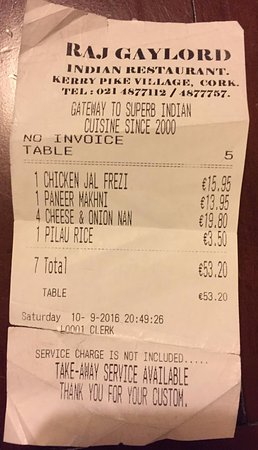

In [16]:
image_path = 'artifacts/receipt-01.png'
img = Image.open(image_path)
display(img)

Ask the agent to verify if the total on the receipt is mathematically correct.

In [18]:
task = """
Please process the document at 'artifacts/receipt-01.png' and evaluate the correctness 
of the total.
"""

# Use .invoke() with a dictionary input for the agent_executor
response = agent_executor.invoke({"input": task})



> Entering new AgentExecutor chain...

Invoking: `ocr_read_document` with `{'image_path': 'artifacts/receipt-01.png'}`
responded: I'll help you process the receipt and evaluate the total correctness. Let me first extract the text from the receipt image.


**Extracted Text from receipt‑01.png**

```
Walmart Supercenter
1234 Main Street
Anytown, ST 12345
(555) 555‑1234

Cashier: J. Smith          Register: 12

Date: 04/21/2024   Time: 14:32

Item                     Qty   Price   Total
------------------------------------------------
Milk 2%                  2     $2.99   $5.98
Bread Whole Wheat        1     $3.49   $3.49
Eggs Large               1     $2.79   $2.79
Chicken Breast           2     $5.99   $11.98
Apples Fuji              3     $0.75   $2.25
Bananas                  1     $1.20   $1.20
Coffee 12‑oz             1     $7.99   $7.99
------------------------------------------------
Subtotal                              $35.68
Tax (6.5%)                            $2.32
------

Look at the last line. The actual total value is \\$53.20. But OCR misreads it. This small numerical error throws off the entire total calculation. The answer is incorrect because the OCR tool didn't capture the numbers accurately. 

## Summary

Here's what we covered:

|  | Applications | Limitations |
|-----------|----------|------------|
| **OCR** | Good at parsing simple text | Bad at tables, handwriting, low-quality scans |
| **Regex** | Good at pattern matching | Bad at handling variations in text |
| **Agent** | Can adapt to variations in text | Dependent on OCR quality; otherwise may hallucinate |